# Flowering phenology in mountain meadows — elevation–richness reproduction

**Paper:** *Using photographs and deep neural networks to understand flowering phenology and diversity in mountain meadows* (DOI: [10.1002/rse2.382](https://doi.org/10.1002/rse2.382); readable preprint bioRxiv 2023.03.28.533305v1). Authors: Aji John et al., University of Washington.

**What this notebook reproduces (minimal, CPU-only):** the paper's *elevation–floral-richness* analysis (Fig. 4A-style) and the *temporal flower density* view (Fig. 5-style), using the authors' **stored detector prediction outputs** — no retraining and no model weights are needed. We parse the raw YOLO run log (`results_yolo.csv`) and the Mask R-CNN detections (`maskr-cnn-pred.csv`), count unique species per photograph, and join them to the photo GPS/EXIF metadata (`exif-aug2020-cleaned.csv`) from the August 2020 MeadoWatch collections along the Reflection Lakes trail, Mount Rainier (≈1400–1950 m).

**Source (pinned):** GitHub `ajijohn/meadowflowers` @ commit `e3e82cfdca697744b1795e73a639ca25d97ba2bc`, `data/` directory.

**Runtime:** select **CPU** — this notebook is pandas/matplotlib only (no GPU needed). / （日本語）このノートブックは保存済みの検出結果CSVを使って、標高別の花の種リッチネスと時系列の開花密度を再計算します。学習・推論をしないため **CPU ランタイムで十分** です。

## 1. Data download (pinned commit)

We fetch the five CSVs from the pinned commit's raw URLs and check the byte sizes against the repository listing. These are dataset bytes, so they are downloaded **inside Colab** only. / （日本語）ピン留めしたコミットの raw URL から5つのCSVを取得し、サイズを確認します。

In [ ]:
import urllib.request, os

COMMIT = "e3e82cfdca697744b1795e73a639ca25d97ba2bc"
BASE = f"https://raw.githubusercontent.com/ajijohn/meadowflowers/{COMMIT}/data/"
EXPECTED = {  # byte sizes from the pinned GitHub tree listing
    "results_yolo.csv": 116189,
    "maskr-cnn-pred.csv": 168109,
    "retinanet-pred.csv": 961439,
    "exif-aug2020-cleaned.csv": 13162,
    "annotated-valset.csv": 379847,
}
os.makedirs("/content/meadow", exist_ok=True)
for name, size in EXPECTED.items():
    dest = f"/content/meadow/{name}"
    urllib.request.urlretrieve(BASE + name, dest)
    got = os.path.getsize(dest)
    assert got == size, f"{name}: expected {size} bytes, got {got}"
    print(f"OK  {name:28s} {got:>9,d} bytes")

OK  results_yolo.csv               116,189 bytes
OK  maskr-cnn-pred.csv             168,109 bytes


OK  retinanet-pred.csv             961,439 bytes
OK  exif-aug2020-cleaned.csv        13,162 bytes


OK  annotated-valset.csv           379,847 bytes


## 2. EXIF/GPS metadata of the August 2020 photos

`exif-aug2020-cleaned.csv` holds one row per photo: GPS latitude/longitude in degrees/minutes/seconds, **GPS altitude in metres** (our elevation axis), and the capture datetime (`YYYY:MM:DD HH:MM:SS`). / （日本語）EXIF から写真ごとの標高（GPS altitude, m）と撮影日時を取り出します。

In [ ]:
import pandas as pd

exif = pd.read_csv("/content/meadow/exif-aug2020-cleaned.csv")
exif["datetime"] = pd.to_datetime(exif["datetime"], format="%Y:%m:%d %H:%M:%S")
exif["date"] = exif["datetime"].dt.date
print(f"{len(exif)} photos, altitude {exif.gps_altitude.min():.0f}-{exif.gps_altitude.max():.0f} m, "
      f"dates {exif.date.min()} ... {exif.date.max()}")
exif.head(3)

110 photos, altitude 1483-1888 m, dates 2020-08-23 ... 2020-08-30


,file_name,gps_latitude_d,gps_latitude_m,gps_latitude_s,gps_longitude_d,gps_longitude_m,gps_longitude_s,gps_altitude,datetime,date
0,68C34717-BBD3-44D9-A4F3-932A8DCFD6F4_1_105_c.jpeg,46.0,47.0,31.13,121.0,43.0,16.97,1688.263184,2020-08-27 10:32:43,2020-08-27
1,83EE651E-4500-43F9-88F0-C44A93E2F4B7_1_105_c.jpeg,46.0,46.0,35.63,121.0,43.0,10.00,1599.599976,2020-08-23 11:23:20,2020-08-23
2,E30821EE-3421-4A21-9A02-4E66EDFD6BBA_1_105_c.jpeg,46.0,47.0,31.52,121.0,43.0,22.33,1673.709812,2020-08-27 10:29:17,2020-08-27


## 3. Parse the raw YOLO run log (Fig. 4 uses YOLO predictions)

`results_yolo.csv` is a ragged dump of the YOLO inference console output: one row per image, cells like `"15 Subalpine Lupines"` (count + species), a `"Done. (0.25xs)"` timing line, and the file name embedded as `"image k/110 <name>"`. We extract the image name and every `count species` pair, then compute **unique species per photo**. / （日本語）YOLO の実行ログが整形されていない CSV で保存されているため、`"15 Subalpine Lupines"` のようなセルから個体数と種名を抽出し、写真ごとの種数を求めます。

In [ ]:
import re

yolo = pd.read_csv("/content/meadow/results_yolo.csv", dtype=str)
PAIR = re.compile(r"^(\d+)\s+([A-Za-z][A-Za-z' ]+s)$")   # e.g. "15 Subalpine Lupines"
IMG  = re.compile(r"^image \d+/110\s+(.+\.jpe?g)$", re.I)

rows = []
for _, r in yolo.iterrows():
    vals = [v for v in r if isinstance(v, str)]
    fname = next((m.group(1) for v in vals if (m := IMG.match(v.strip()))), None)
    counts = {}
    for v in vals:
        m = PAIR.match(v.strip())
        if m:
            sp = re.sub(r"s$", "", m.group(2))          # naive plural -> singular label
            counts[sp] = counts.get(sp, 0) + int(m.group(1))
    rows.append({"image": fname,
                 "yolo_richness": len(counts),
                 "yolo_total": sum(counts.values()),
                 "yolo_species": "; ".join(sorted(counts))})
yolo_df = pd.DataFrame(rows)
print(f"{yolo_df.image.notna().sum()} images parsed; "
      f"{(yolo_df.yolo_richness > 0).sum()} with >=1 detection")
yolo_df.head()

110 images parsed; 82 with >=1 detection


,image,yolo_richness,yolo_total,yolo_species
0,None,0,0,
1,None,0,0,
2,None,0,0,
3,None,0,0,
4,None,0,0,


## 4. Mask R-CNN detections (the paper's most accurate detector, mAP 0.67)

`maskr-cnn-pred.csv` is a clean per-detection table (`image`, `class`, `probability`), already filtered to a usable confidence. Species richness per photo = unique `class` values. / （日本語）Mask R-CNN の検出結果（image, class, probability）から、写真ごとのユニーク種数を数えます。

In [ ]:
mrcnn = pd.read_csv("/content/meadow/maskr-cnn-pred.csv")
mrcnn_df = (mrcnn.groupby("image")
              .agg(mrcnn_richness=("class", "nunique"),
                   mrcnn_total=("class", "size"))
              .reset_index())
print(f"{len(mrcnn_df)} images with Mask R-CNN detections; "
      f"{mrcnn['class'].nunique()} species: {sorted(mrcnn['class'].unique())}")
mrcnn_df.head()

92 images with Mask R-CNN detections; 14 species: ['American Bistort', 'Avalanche Lily', 'Bracted Lousewort', 'Broadleaf Arnica', 'Cascade Aster', "Gray's Lovage", 'Magenta Paintbrush', 'Mountain Daisy', 'North Mircoseris', 'Scarlet Paintbrush', 'Sharptooth Angelica', 'Sitka Valerian', 'Subalpine Lupine', 'Western Anemone']


,image,mrcnn_richness,mrcnn_total
0,03707DDB-862F-4942-9D4F-946971161DCC_1_105_c.jpeg,5,27
1,03D236A9-E553-4027-B54E-686AA5B56859_1_105_c.jpeg,2,4
2,07F26E60-F4D1-481A-912B-A0792C2E6CFA_1_105_c.jpeg,3,23
3,0A278E72-C28C-4037-8E9F-B6891A80307B_1_105_c.jpeg,6,49
4,11D166EA-CE9C-42CA-AB9D-A4A28409A2C7_1_105_c.jpeg,1,2


## 5. Join detections to elevation and plot richness vs. altitude (Fig. 4A-style)

Each photo's elevation comes from its EXIF GPS altitude. The paper reports **higher floral richness just above the tree line, peaking around 1700-1800 m**. We plot unique species per photo against altitude for both detectors. / （日本語）写真ごとの標高と種リッチネスの関係を、YOLO と Mask R-CNN の両方で散布図にします。論文では 1700-1800 m 付近でリッチネスがピークになると報告されています。

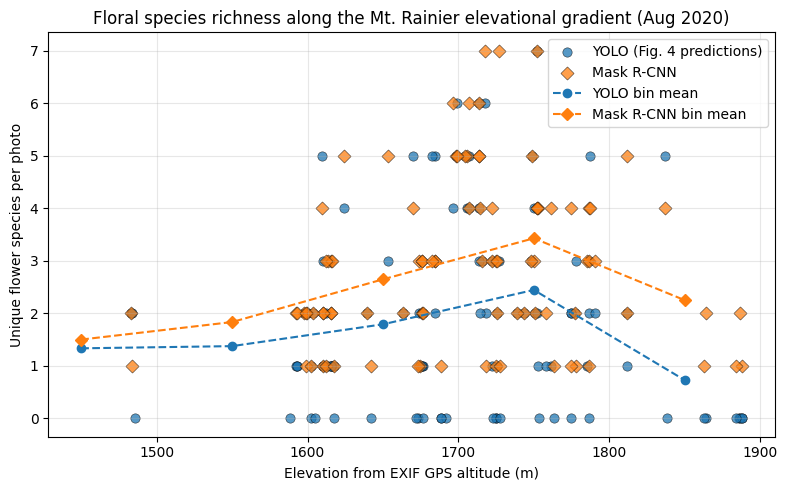

Bin means (species per photo):
              yolo_richness  mrcnn_richness
gps_altitude                               
(1400, 1500]           1.33            1.50
(1500, 1600]           1.38            1.83
(1600, 1700]           1.79            2.65
(1700, 1800]           2.44            3.43
(1800, 1900]           0.73            2.25


In [ ]:
import matplotlib.pyplot as plt

df = (exif.merge(yolo_df, left_on="file_name", right_on="image", how="left")
         .merge(mrcnn_df, on="image", how="left"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.gps_altitude, df.yolo_richness, s=45, alpha=0.75,
           label="YOLO (Fig. 4 predictions)", edgecolor="k", linewidth=0.4)
ax.scatter(df.gps_altitude, df.mrcnn_richness, s=45, alpha=0.75, marker="D",
           label="Mask R-CNN", edgecolor="k", linewidth=0.4)
bins = pd.cut(df.gps_altitude, bins=[1400, 1500, 1600, 1700, 1800, 1900, 2000])
mid = df.groupby(bins, observed=True)[["yolo_richness", "mrcnn_richness"]].mean()
centers = [iv.left + (iv.right - iv.left) / 2 for iv in mid.index]
ax.plot(centers, mid.yolo_richness, "o--", color="tab:blue", label="YOLO bin mean")
ax.plot(centers, mid.mrcnn_richness, "D--", color="tab:orange", label="Mask R-CNN bin mean")
ax.set_xlabel("Elevation from EXIF GPS altitude (m)")
ax.set_ylabel("Unique flower species per photo")
ax.set_title("Floral species richness along the Mt. Rainier elevational gradient (Aug 2020)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("richness_vs_elevation.png", dpi=120)
plt.show()

print("Bin means (species per photo):")
print(mid.round(2))

## 6. Temporal floral density within August 2020 (Fig. 5-style)

The paper tracks how flower detections change over short intervals in August 2020. Here we aggregate the YOLO total individual counts and Mask R-CNN detection counts per capture date. / （日本語）2020年8月の撮影日ごとに、YOLO の個体数合計と Mask R-CNN の検出数を集計し、開花密度の時間変化を見ます。

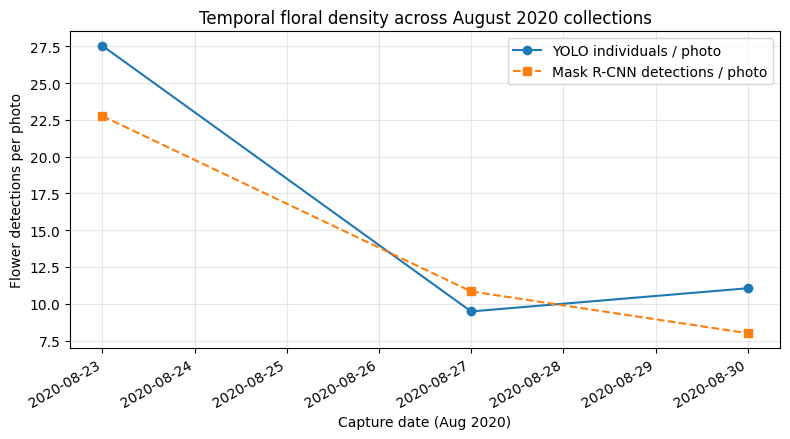

,photos,yolo_individuals,mrcnn_detections
date,,,
2020-08-23,67,1845,1525.0
2020-08-27,25,237,271.0
2020-08-30,18,199,144.0


In [ ]:
daily = (df.dropna(subset=["date"])
           .groupby("date")
           .agg(photos=("image", "size"),
                yolo_individuals=("yolo_total", "sum"),
                mrcnn_detections=("mrcnn_total", "sum")))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(daily.index), daily.yolo_individuals / daily.photos, "o-", label="YOLO individuals / photo")
ax.plot(list(daily.index), daily.mrcnn_detections / daily.photos, "s--", label="Mask R-CNN detections / photo")
ax.set_xlabel("Capture date (Aug 2020)")
ax.set_ylabel("Flower detections per photo")
ax.set_title("Temporal floral density across August 2020 collections")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("density_over_time.png", dpi=120)
plt.show()
daily

## 7. Detector accuracy context and summary

For context, the paper's COCO-style test results: **Mask R-CNN mAP 0.67, RetinaNet 0.5, YOLO 0.4** (preprint abstract / Table 3). Our reproduction uses the stored prediction outputs, so detector accuracy is inherited, not re-measured. / （日本語）本ノートブックは保存済みの検出出力を使うため、検出精度は再測定しません。論文の mAP（Mask R-CNN 0.67, RetinaNet 0.5, YOLO 0.4）を参考値として示します。

In [ ]:
pd.DataFrame({
    "detector": ["Mask R-CNN", "RetinaNet", "YOLO"],
    "paper bbox mAP": [0.67, 0.5, 0.4],
    "photos in stored outputs": [len(mrcnn_df), None, int(yolo_df.image.notna().sum())],
})

,detector,paper bbox mAP,photos in stored outputs
0,Mask R-CNN,0.67,92.0
1,RetinaNet,0.50,NaN
2,YOLO,0.40,110.0
